# RT-DETR-L Training

## Config and Paths

In [1]:
import os

DATASET_YAML = '/home/achin/COS40007-Group/dataset/dataset.yaml'
WEIGHTS_PATH = '/home/achin/COS40007-Group/rtdetr-l.pt'
PROJECT_DIR  = '/home/achin/COS40007-Group/runs/defect_detection'
DATASET_ROOT = '/home/achin/COS40007-Group/dataset'

RUN = 'rtdetr_l_v4'
CLASS_NAMES = ['crack', 'pothole', 'wall_peeling']
BACKGROUND_PREFIXES = ('wall-', 'road-')
NC = 3
SPLITS = ['train', 'val', 'test']

IMAGE_DIRS = {s: os.path.join(DATASET_ROOT, s, 'images') for s in SPLITS}
LABEL_DIRS = {s: os.path.join(DATASET_ROOT, s, 'labels') for s in SPLITS}

print("Paths configured:")
for s in SPLITS:
    all_imgs = [f for f in os.listdir(IMAGE_DIRS[s]) if f.endswith('.jpg')]
    bg_imgs  = [f for f in all_imgs if f.startswith(BACKGROUND_PREFIXES)]
    def_imgs = [f for f in all_imgs if not f.startswith(BACKGROUND_PREFIXES)]
    print(f"  {s}: {len(def_imgs)} defect + {len(bg_imgs)} background = {len(all_imgs)} total")

Paths configured:
  train: 462 defect + 79 background = 541 total
  val: 99 defect + 18 background = 117 total
  test: 99 defect + 18 background = 117 total


## Dataset Exploratory Data Analysis


TRAIN: 541 images
  crack: 164 annotations
  pothole: 398 annotations
  wall_peeling: 233 annotations
  background (empty): 84 images
  bg/defect ratio: 0.11 ✅

VAL: 117 images
  crack: 34 annotations
  pothole: 82 annotations
  wall_peeling: 49 annotations
  background (empty): 18 images
  bg/defect ratio: 0.11 ✅

TEST: 117 images
  crack: 36 annotations
  pothole: 65 annotations
  wall_peeling: 47 annotations
  background (empty): 18 images
  bg/defect ratio: 0.12 ✅


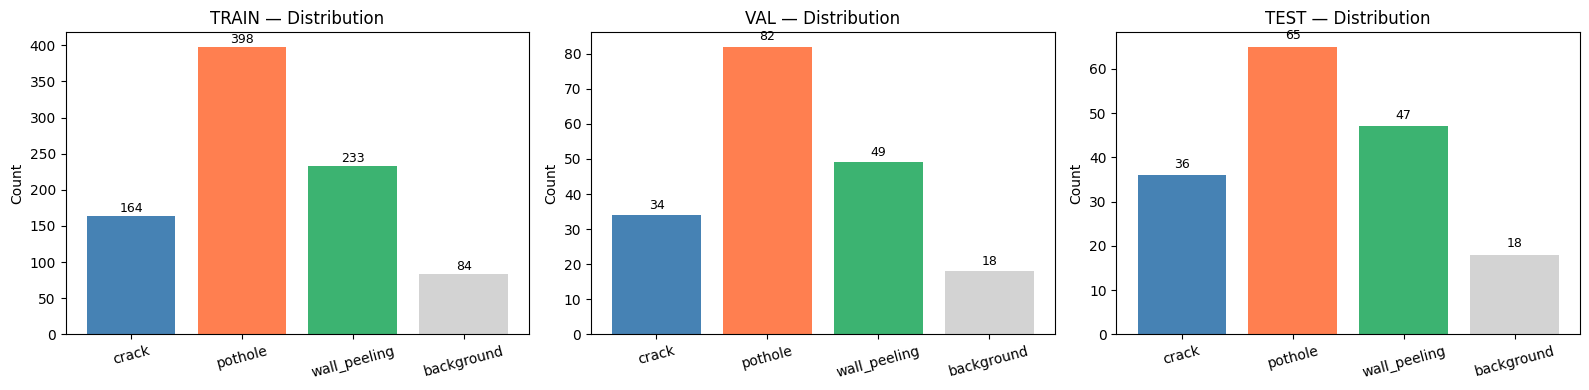

In [2]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def count_labels(split):
    label_dir = Path(LABEL_DIRS[split])
    class_counts = Counter()
    bg_count = 0
    for txt in label_dir.glob('*.txt'):
        content = txt.read_text().strip()
        if not content:
            bg_count += 1
        else:
            for line in content.splitlines():
                if line.strip():
                    cls = int(line.split()[0])
                    class_counts[cls] += 1
    return class_counts, bg_count

for split in SPLITS:
    counts, bg_count = count_labels(split)
    total_images = len(list(Path(IMAGE_DIRS[split]).glob('*.jpg')))
    print(f"\n{split.upper()}: {total_images} images")
    for cls_id in sorted(counts):
        print(f"  {CLASS_NAMES[cls_id]}: {counts[cls_id]} annotations")
    print(f"  background (empty): {bg_count} images")
    ratio = bg_count / max(sum(counts.values()), 1)
    print(f"  bg/defect ratio: {ratio:.2f} {'⚠️ consider reducing' if ratio > 0.5 else '✅'}")

# Bar chart — defect classes only, background shown separately
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split in zip(axes, SPLITS):
    counts, bg_count = count_labels(split)
    names  = [CLASS_NAMES[i] for i in sorted(counts)] + ['background']
    values = [counts[i] for i in sorted(counts)] + [bg_count]
    colors = ['steelblue', 'coral', 'mediumseagreen', 'lightgray']
    bars = ax.bar(names, values, color=colors)
    ax.set_title(f'{split.upper()} — Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

## Visualise Sample Annotations

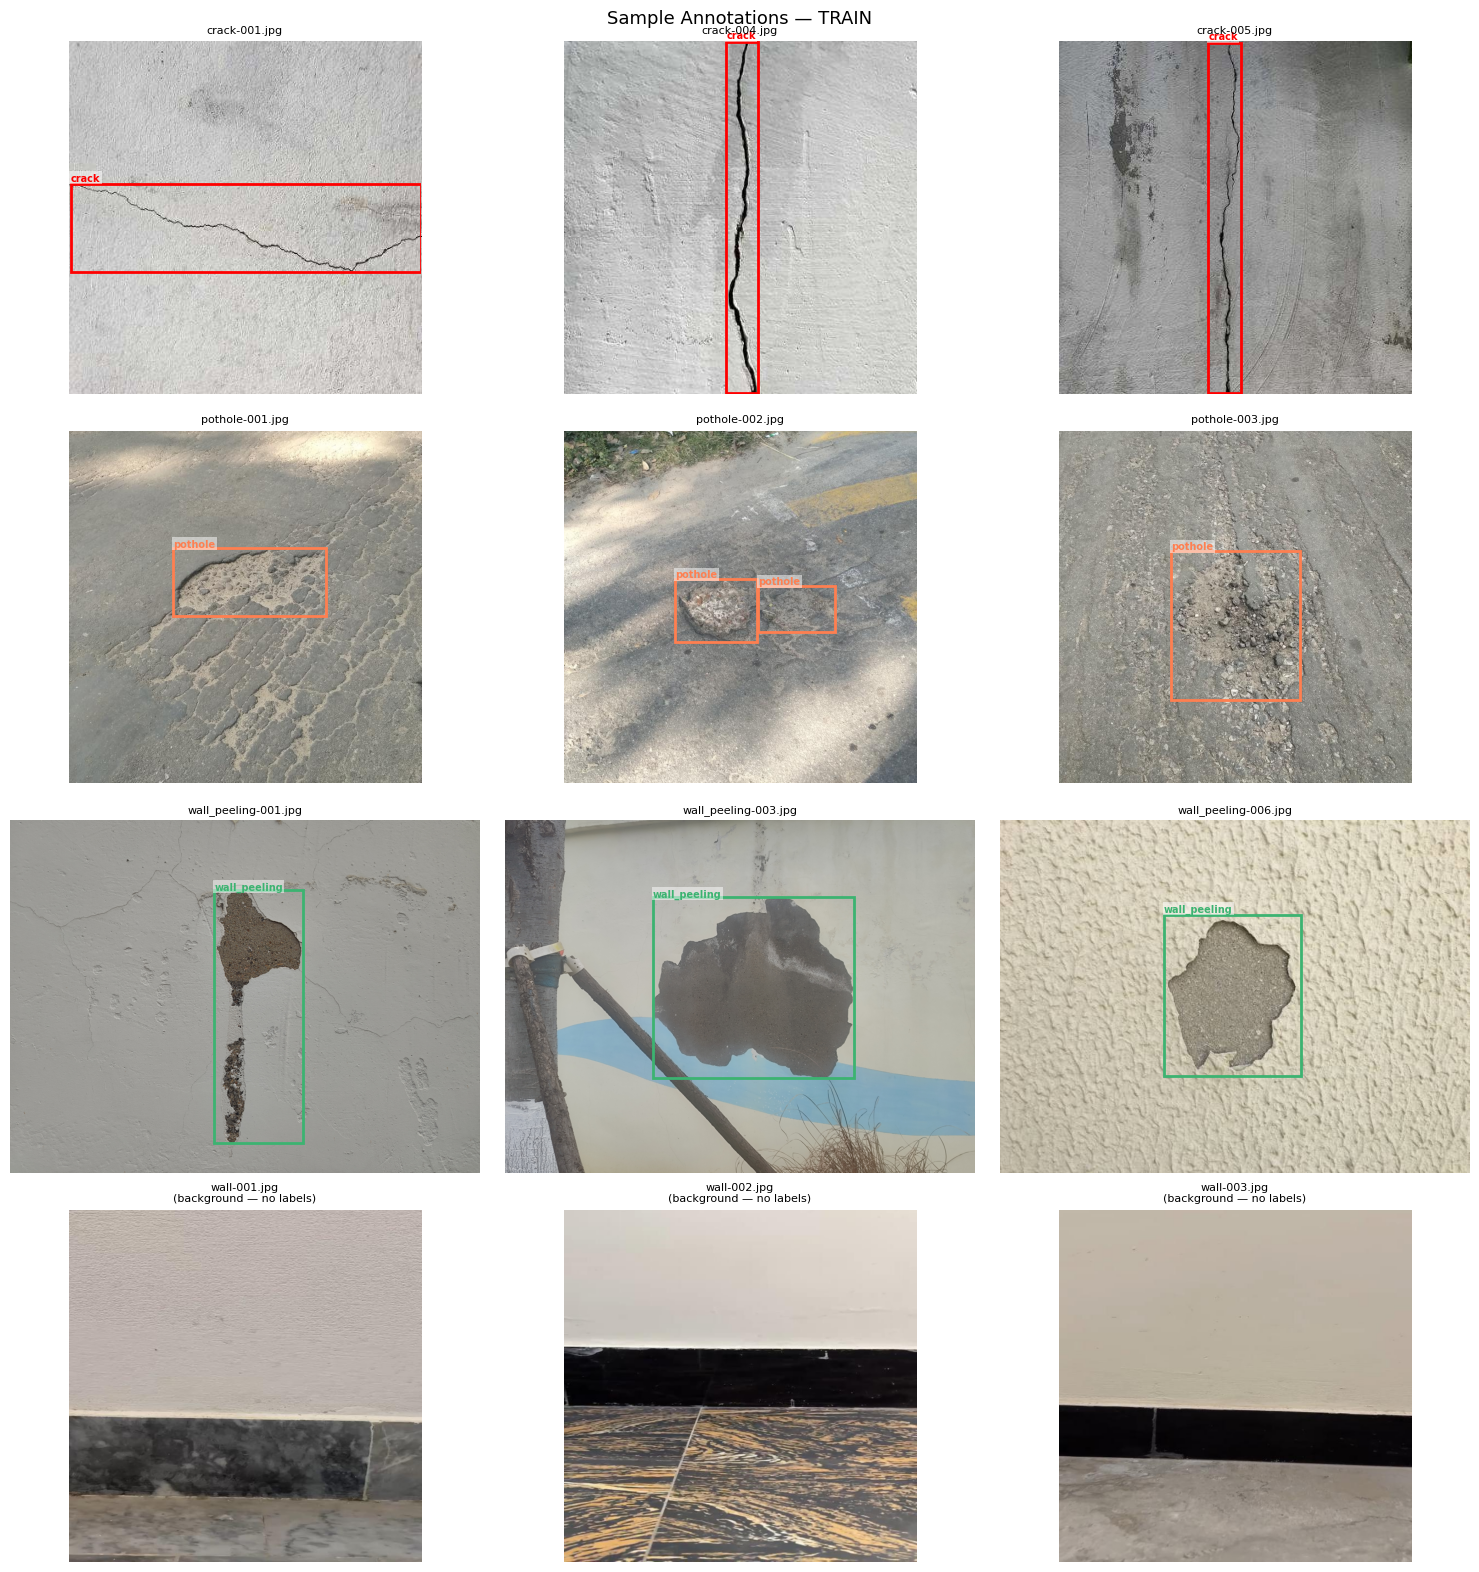

In [3]:
import matplotlib.patches as patches
from PIL import Image

def visualize_samples_by_class(split, n_per_class=3):
    img_dir = Path(IMAGE_DIRS[split])
    lbl_dir = Path(LABEL_DIRS[split])
    COLORS  = ['red', 'coral', 'mediumseagreen']

    # defect rows + 1 background row
    total_rows = NC + 1
    fig, axes = plt.subplots(total_rows, n_per_class, figsize=(5 * n_per_class, 4 * total_rows))

    # --- defect class rows ---
    for row, cls_name in enumerate(CLASS_NAMES):
        cls_imgs = sorted(img_dir.glob(f'{cls_name}-*.jpg'))[:n_per_class]

        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')

            if col >= len(cls_imgs):
                ax.set_title(f'{cls_name} — no sample', fontsize=9)
                continue

            img_path = cls_imgs[col]
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            ax.imshow(img)
            ax.set_title(f'{img_path.name}', fontsize=8)

            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.split()
                    if not parts:
                        continue
                    c, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=2, edgecolor=COLORS[c % len(COLORS)], facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES[c], color=COLORS[c % len(COLORS)],
                            fontsize=7, fontweight='bold',
                            bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))

    bg_imgs = []
    for prefix in BACKGROUND_PREFIXES:
        bg_imgs.extend(sorted(img_dir.glob(f'{prefix}*.jpg')))
    bg_imgs = bg_imgs[:n_per_class]

    for col in range(n_per_class):
        ax = axes[NC][col]
        ax.axis('off')
        if col < len(bg_imgs):
            img = Image.open(bg_imgs[col]).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{bg_imgs[col].name}\n(background — no labels)', fontsize=8)
        else:
            ax.set_title('background — no sample', fontsize=9)

    plt.suptitle(f'Sample Annotations — {split.upper()}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'sample_annotations_{split}.png'), dpi=150)
    plt.show()

visualize_samples_by_class('train', n_per_class=3)

## Training

In [4]:
from pathlib import Path

for split in SPLITS:
    cache = Path(LABEL_DIRS[split]).parent / 'labels.cache'
    if cache.exists():
        cache.unlink()
        print(f"Deleted cache: {cache}")
    else:
        print(f"No cache found for {split} — OK")

Deleted cache: /home/achin/COS40007-Group/dataset/train/labels.cache
Deleted cache: /home/achin/COS40007-Group/dataset/val/labels.cache
Deleted cache: /home/achin/COS40007-Group/dataset/test/labels.cache


In [ ]:
from ultralytics import RTDETR

os.makedirs(PROJECT_DIR, exist_ok=True)

model = RTDETR(WEIGHTS_PATH)

results = model.train(
    data=DATASET_YAML,
    epochs=300,
    imgsz=640,
    batch=16,
    lr0=1e-4,
    lrf=0.001,
    warmup_epochs=5,
    warmup_bias_lr=0.1,
    optimizer='AdamW',
    weight_decay=1e-4,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.1,
    scale=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    degrees=10.0,
    translate=0.1,
    workers=16,
    save=True,
    plots=True,
    amp=False,
    device=0,
    project=PROJECT_DIR,
    name=RUN,
    exist_ok=True,
)

print("Training complete.")
print(f"Best weights saved to: {PROJECT_DIR}/{RUN}/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/achin/COS40007-Group/dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/achin/COS40007-Group/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_v4, nbs=64, nms=False, opset=None,

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 401.5±238.1 MB/s, size: 85.3 KB)
val: Scanning /home/achin/COS40007-Group/dataset/val/labels.cache... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 5.0Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 143 weight(decay=0.0), 206 weight(decay=0.0001), 226 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/labels.jpg... 
Image sizes 640 train, 640 val
Using 16 dataloader workers
Logging results to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4
Starting training for 300 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


## Validation on Val Set

In [ ]:
best_weights = os.path.join(PROJECT_DIR, RUN, 'weights', 'best.pt')
trained_model = RTDETR(best_weights)

val_metrics = trained_model.val(
    data=DATASET_YAML,
    split='val',
    plots=True,
    save_json=True,
    project=PROJECT_DIR,
    name=f'{RUN}_val',
    exist_ok=True,
)

print("\n--- Val Metrics ---")
print(f"mAP@50:     {val_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {val_metrics.box.map:.4f}")
print(f"Precision:  {val_metrics.box.mp:.4f}")
print(f"Recall:     {val_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {val_metrics.box.ap50[i]:.4f}")

## Evaluation on Test Set

In [ ]:
test_metrics = trained_model.val(
    data=DATASET_YAML,
    split='test',
    plots=True,
    project=PROJECT_DIR,
    name=f'{RUN}_test',
    exist_ok=True,
)

print("\n--- Test Metrics ---")
print(f"mAP@50:     {test_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {test_metrics.box.map:.4f}")
print(f"Precision:  {test_metrics.box.mp:.4f}")
print(f"Recall:     {test_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {test_metrics.box.ap50[i]:.4f}")

## Training Curves

In [ ]:
import pandas as pd
import matplotlib.image as mpimg

results_csv = os.path.join(PROJECT_DIR, RUN, 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plots = [
    ('train/giou_loss',       'Train GIoU Loss',  'steelblue'),
    ('train/cls_loss',        'Train Cls Loss',   'coral'),
    ('train/l1_loss',         'Train L1 Loss',    'goldenrod'),
    ('val/giou_loss',         'Val GIoU Loss',    'navy'),
    ('val/cls_loss',          'Val Cls Loss',     'firebrick'),
    ('val/l1_loss',           'Val L1 Loss',      'darkorange'),
    ('metrics/mAP50(B)',      'mAP@50',           'green'),
    ('metrics/mAP50-95(B)',   'mAP@50-95',        'darkgreen'),
    ('metrics/precision(B)',  'Precision',        'purple'),
    ('metrics/recall(B)',     'Recall',           'orange'),
    ('lr/pg0',                'LR (backbone)',    'gray'),
    ('lr/pg1',                'LR (weights)',     'darkgray'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.suptitle('RT-DETR Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Inference and Visualisation on Test Images

In [ ]:
trained_model.predict(
    source=IMAGE_DIRS['test'],
    conf=0.25,
    iou=0.5,
    save=True,
    project=PROJECT_DIR,
    name=f'{RUN}_predictions',
    exist_ok=True,
)

pred_dir = Path(PROJECT_DIR) / f'{RUN}_predictions'

fig, axes = plt.subplots(NC, 3, figsize=(15, 4 * NC))
for row, cls_name in enumerate(CLASS_NAMES):
    cls_preds = sorted(pred_dir.glob(f'{cls_name}-*.jpg'))[:3]
    for col in range(3):
        ax = axes[row][col]
        ax.axis('off')
        if col < len(cls_preds):
            ax.imshow(mpimg.imread(cls_preds[col]))
            ax.set_title(cls_preds[col].name, fontsize=8)
        else:
            ax.set_title(f'{cls_name} — no prediction saved', fontsize=8)

plt.suptitle('RT-DETR Predictions — Test Set (by class)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'prediction_samples.png'), dpi=150)
plt.show()

## Display Evaluation Plots

In [ ]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('PR_curve.png',                    'Precision-Recall Curve'),
    ('P_curve.png',                     'Precision Curve'),
    ('R_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")

## Inference Speed Benchmark

In [ ]:
import time

test_imgs = list(Path(IMAGE_DIRS['test']).glob('*.jpg'))[:50]

# Warmup
trained_model.predict(source=[str(test_imgs[0])], conf=0.25, verbose=False)

# Timed run
start = time.time()
trained_model.predict(source=[str(p) for p in test_imgs], conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(test_imgs) / elapsed
print(f"Images tested : {len(test_imgs)}")
print(f"Total time    : {elapsed:.2f}s")
print(f"FPS           : {fps:.1f}")
print(f"ms/image      : {1000/fps:.1f}")

## Display Evaluation Plots

In [ ]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('BoxPR_curve.png',                    'Precision-Recall Curve'),
    ('BoxP_curve.png',                     'Precision Curve'),
    ('BoxR_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")